In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import marimo as mo

from wigglystuff import Slider2D

In [ ]:
#! parametros estilo
Texto_latex = True
Plot_dark = True

tam_fuente = 12

if Plot_dark:
  plt.style.use('dark_background')
else:
  plt.style.use('default')

#! Configurar texto en LaTeX
if Texto_latex:
  plt.rcParams.update({
    "text.usetex": True,
    # "font.family": "Helvetica"
    "font.size": tam_fuente,
    })  

In [ ]:
def func_f(x, y):
  return x ** 2 + y ** 2

def draw_riemann(m, n, intervalo_x=(0, 5), intervalo_y=(0, 5), intervalo_x_graf=(-0.25, 5.25), intervalo_y_graf=(-0.25, 5.25), intervalo_z_graf=(0, 50),alpha=1, beta=1):
  largo_x = intervalo_x[1] - intervalo_x[0]
  largo_y = intervalo_y[1] - intervalo_y[0]

  fig = plt.figure(figsize=(10, 10))
  ax = fig.add_subplot(111, projection='3d')
  ax.set_xlim(intervalo_x_graf)
  ax.set_ylim(intervalo_y_graf)
  ax.set_zlim(intervalo_z_graf)

  dx = largo_x / m
  dy = largo_y / n

  # Mallas no estrictamente necesarias para las barras, pero útiles para calcular zmin/zmax
  # x = np.linspace(*intervalo_x, m + 1)
  # y = np.linspace(*intervalo_y, n + 1)
  # X, Y = np.meshgrid(x, y)
  # Z = func_f(X, Y)

  vol_aprox = 0.0
  # zmin = np.min(Z)
  # zmax = np.max(Z)
  zmin = intervalo_z_graf[0]
  zmax = intervalo_z_graf[1]

  for i in range(m):
    for j in range(n):
      x_i = intervalo_x[0] + i * dx
      y_j = intervalo_y[0] + j * dy
      z0 = 0
      dz = func_f(x_i + alpha*dx, y_j + beta*dy)
      color = plt.cm.gnuplot((dz - zmin) / (zmax - zmin) if zmax > zmin else 0)
      ax.bar3d(x_i, y_j, z0, dx, dy, dz, color=color, alpha=0.9, shade=True)
      vol_aprox += dz * dx * dy

  ax.set_xlabel('$x$')
  ax.set_ylabel('$y$')
  ax.set_zlabel('$z$')
  ax.set_title(f'Suma de Riemann de $f(x,y)=x^2+y^2$ ($m={m}$, $n={n}$)')

  return fig, vol_aprox

In [ ]:
slider_m = mo.ui.slider(0, 16, 1, 4, label="$m$", show_value=True)
slider_n = mo.ui.slider(0, 16, 1, 4, label="$m$", show_value=True)
slider_punto = mo.ui.anywidget(Slider2D(width=250,height=250,x_bounds=(0,1),y_bounds=(0,1),x=1,y=1))

In [ ]:
m = slider_m.value
n = slider_n.value
a = slider_punto.x
b = slider_punto.y

fig, vol_app = draw_riemann(m,n,alpha=a,beta=b)
# vol_real = sp.integrate(sp.integrate(func_f(sp.Symbol('x'), sp.Symbol('y')), (sp.Symbol('x'), 0, 5)), (sp.Symbol('y'), 0, 5))
# volumen real calculado a mano es 1250/3 que es aproximadamente 416.6666666666667
vol_real = 1250/3


text_vol_app = f'Volumen aproximado: {vol_app:.2f}'
text_vol_real = f'Volumen Real: {vol_real:.2f}'

<span class="markdown prose dark:prose-invert contents"><h1 id="suma-de-riemann-3d"><center>Suma de Riemann 3D</center></h1>
<div style='display: flex;flex: 1;flex-direction: row;justify-content: space-between;align-items: normal;flex-wrap: nowrap;gap: 0.5rem'><div style='display: flex;flex: 1;flex-direction: column;justify-content: flex-start;align-items: normal;flex-wrap: nowrap;gap: 0.5rem'><span>Punto muestra:</span><marimo-ui-element object-id='bkHC-2' random-id='40a8e6cc-2959-f08e-c3c4-0b6bccdb80d3'><marimo-anywidget data-initial-value='{&quot;model_id&quot;:&quot;4177faeea1ad473aad99f32785fbaa4e&quot;}' data-label='null' data-js-url='&quot;./@file/2995-2488726-LiKwvXz6.js&quot;' data-js-hash='&quot;3ecb9222ec3ee7c88f10565061636904&quot;'></marimo-anywidget></marimo-ui-element><marimo-ui-element object-id='bkHC-0' random-id='2b7ec770-4428-55d1-d1cf-f99b0e5b120f'><marimo-slider data-initial-value='4' data-label='&quot;&lt;span class=&#92;&quot;markdown prose dark:prose-invert contents&#92;&quot;&gt;&lt;span class=&#92;&quot;paragraph&#92;&quot;&gt;&lt;marimo-tex class=&#92;&quot;arithmatex&#92;&quot;&gt;||(m||)&lt;/marimo-tex&gt;&lt;/span&gt;&lt;/span&gt;&quot;' data-start='0' data-stop='16' data-step='1' data-steps='[]' data-debounce='false' data-disabled='false' data-orientation='&quot;horizontal&quot;' data-show-value='true' data-include-input='false' data-full-width='false'></marimo-slider></marimo-ui-element><marimo-ui-element object-id='bkHC-1' random-id='cfb6ebd6-e8e5-bd40-28e8-0558eb53d594'><marimo-slider data-initial-value='4' data-label='&quot;&lt;span class=&#92;&quot;markdown prose dark:prose-invert contents&#92;&quot;&gt;&lt;span class=&#92;&quot;paragraph&#92;&quot;&gt;&lt;marimo-tex class=&#92;&quot;arithmatex&#92;&quot;&gt;||(m||)&lt;/marimo-tex&gt;&lt;/span&gt;&lt;/span&gt;&quot;' data-start='0' data-stop='16' data-step='1' data-steps='[]' data-debounce='false' data-disabled='false' data-orientation='&quot;horizontal&quot;' data-show-value='true' data-include-input='false' data-full-width='false'></marimo-slider></marimo-ui-element><span>Volumen aproximado: 585.94</span><span>Volumen Real: 416.67</span></div><marimo-mime-renderer data-mime='&quot;application/vnd.marimo+mimebundle&quot;' data-data='&quot;{&#92;&quot;image/png&#92;&quot;: &#92;&quot;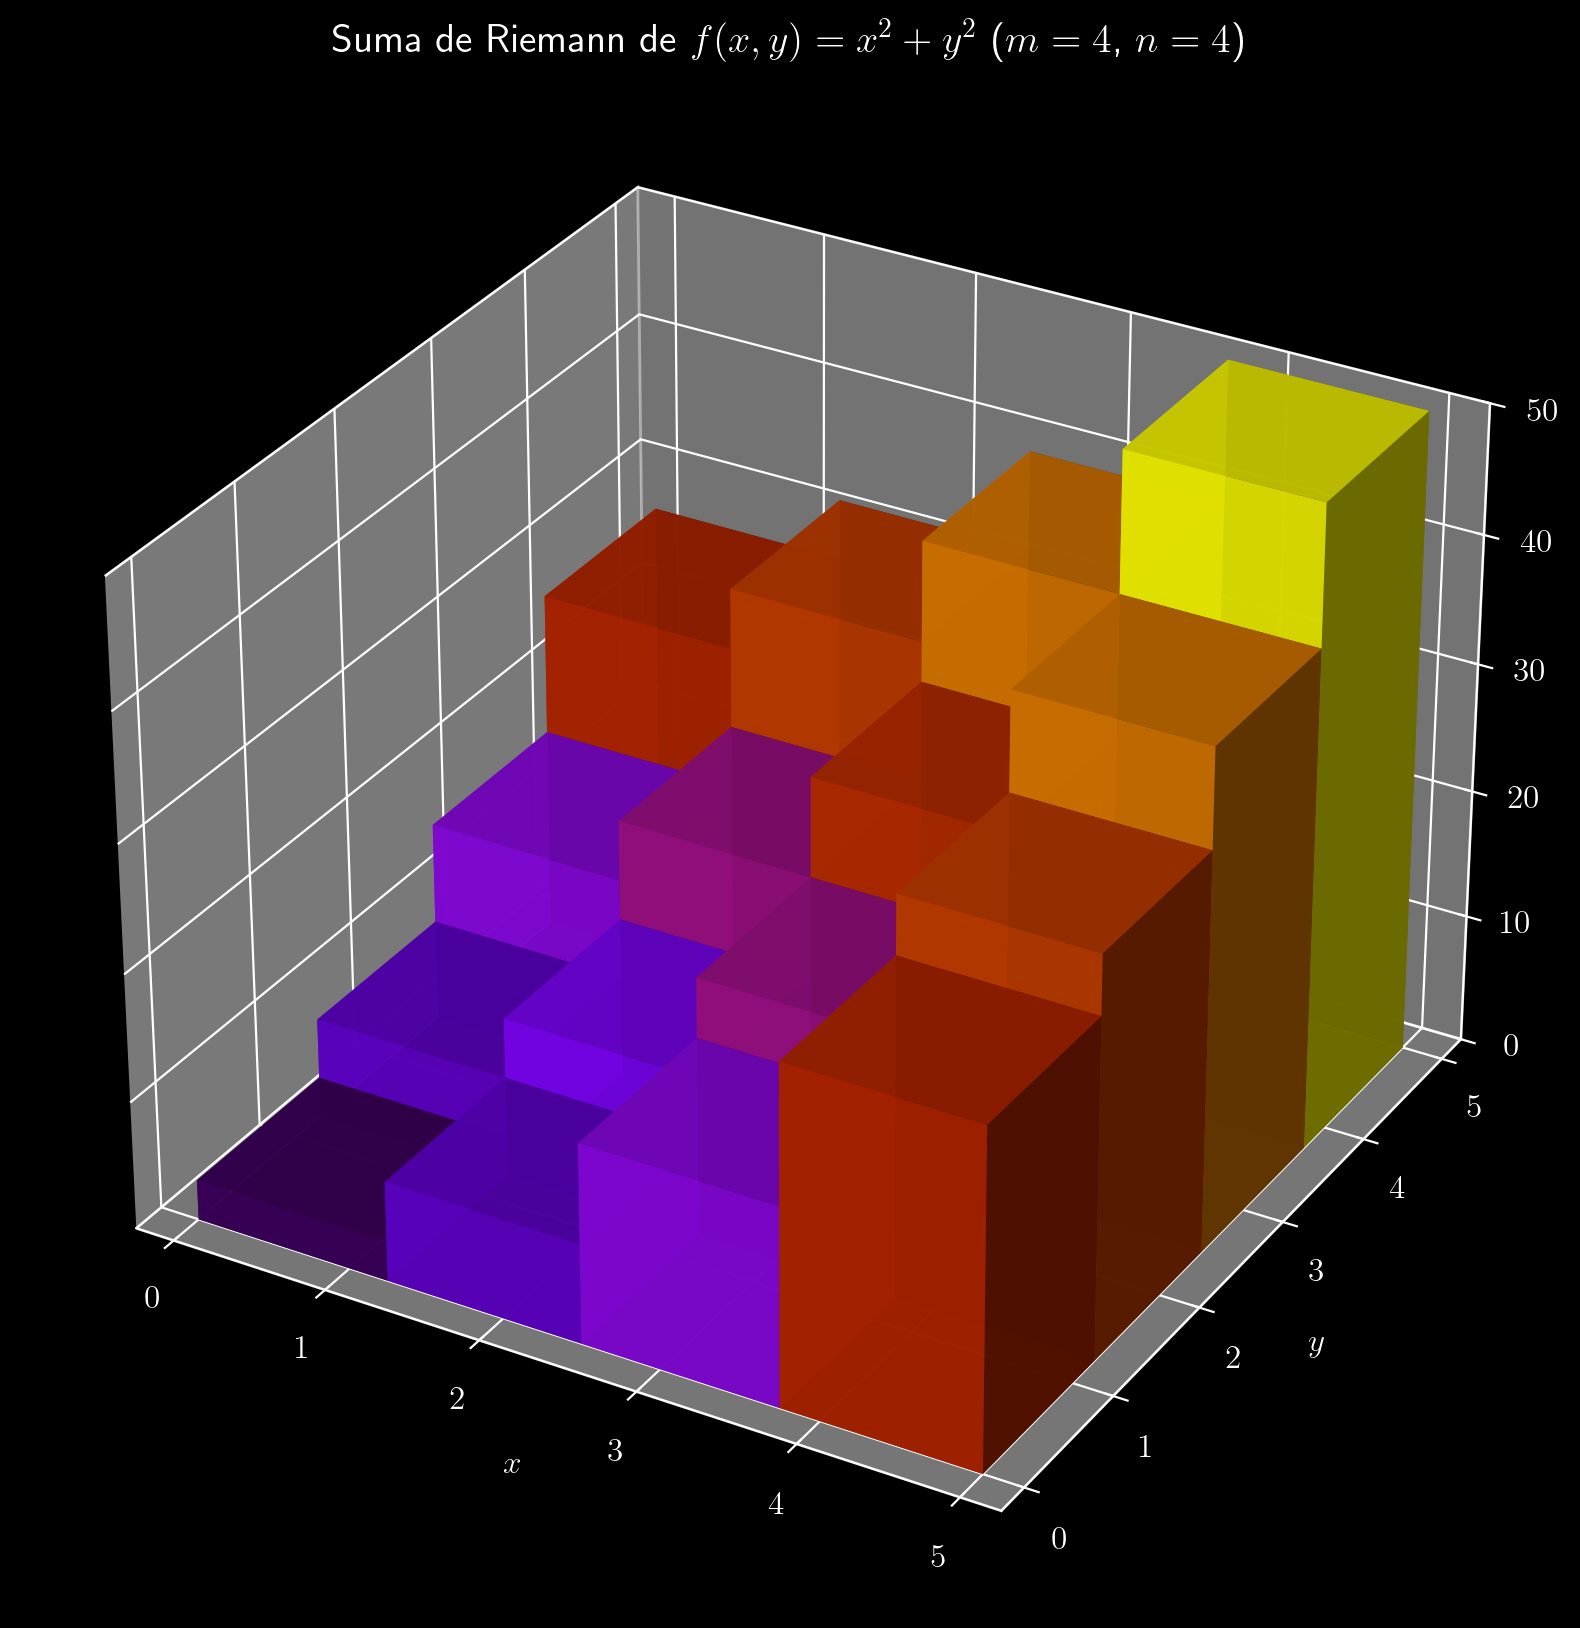&#92;&quot;, &#92;&quot;__metadata__&#92;&quot;: {&#92;&quot;image/png&#92;&quot;: {&#92;&quot;width&#92;&quot;: 790, &#92;&quot;height&#92;&quot;: 814}}}&quot;'></marimo-mime-renderer></div></span>

In [ ]:
mo.md(f"""
# <center>Suma de Riemann 3D</center>
  {mo.hstack([mo.vstack(["Punto muestra:",slider_punto,slider_m,slider_n,text_vol_app,text_vol_real]),mo.as_html(fig)])}
""")